# 03 – Feature Engineering

---

### Vad gör vi i den här notebooken?

Vi skapar features från rådata som ML-modellerna använder för att identifiera 
bull och bear marknader.

| Kategori | Features | Syfte |
|----------|----------|-------|
| **Volatilitet** |  Vol_60d| Mäter marknadens oro |
| **Volym** | Rel_Volume | Bekräftar prisrörelser |

**Input:** `data/sp500_labeled.csv`, `data/bitcoin_labeled.csv`  
**Output:** `data/sp500_features.csv`, `data/bitcoin_features.csv`

## 1. Importera bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR    = '../data'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Läs in etiketterad data

Vi läser in de etiketterade filerna från `02_labeling.ipynb` som innehåller OHLCV-data, Regime och Return.

In [2]:
assets = {}

files = {
    'SP500':   'sp500_labeled.csv',
    'Bitcoin': 'bitcoin_labeled.csv',
}

for name, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    df   = pd.read_csv(path, index_col='Date', parse_dates=True)
    assets[name] = df
    print(f'✓ {name}: {len(df)} rader, kolumner: {list(df.columns)}')

✓ SP500: 6539 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return']
✓ Bitcoin: 4124 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return']


## 3. Volatilitets-feature

Volatilitet mäter marknadens osäkerhet och oro. Hög volatilitet är ett
klassiskt kännetecken för björnmarknader – under krascher som 2008 och
2020 stiger dagliga svängningar dramatiskt.

**Volatility_60** – rullande standardavvikelse av dagliga avkastningar
över 60 handelsdagar (~3 månader). Vi valde 60 dagar för att:

- Filtrera bort kortsiktigt brus som inte reflekterar regimskiften
- Ge ett stabilt kvartalsvist volatilitetsmått som är robust mot enstaka extremdagar

In [3]:
def add_volatility_feature(df: pd.DataFrame) -> pd.DataFrame:
    ret = df['Return']

    # Rullande volatilitet 60 dagar
    df['Volatility_60'] = ret.rolling(60).std()

    return df

for name in assets:
    assets[name] = add_volatility_feature(assets[name])
    print(f'✓ {name}: Volatility_60 tillagd')

✓ SP500: Volatility_60 tillagd
✓ Bitcoin: Volatility_60 tillagd


### Visualisera volatilitet för sp500

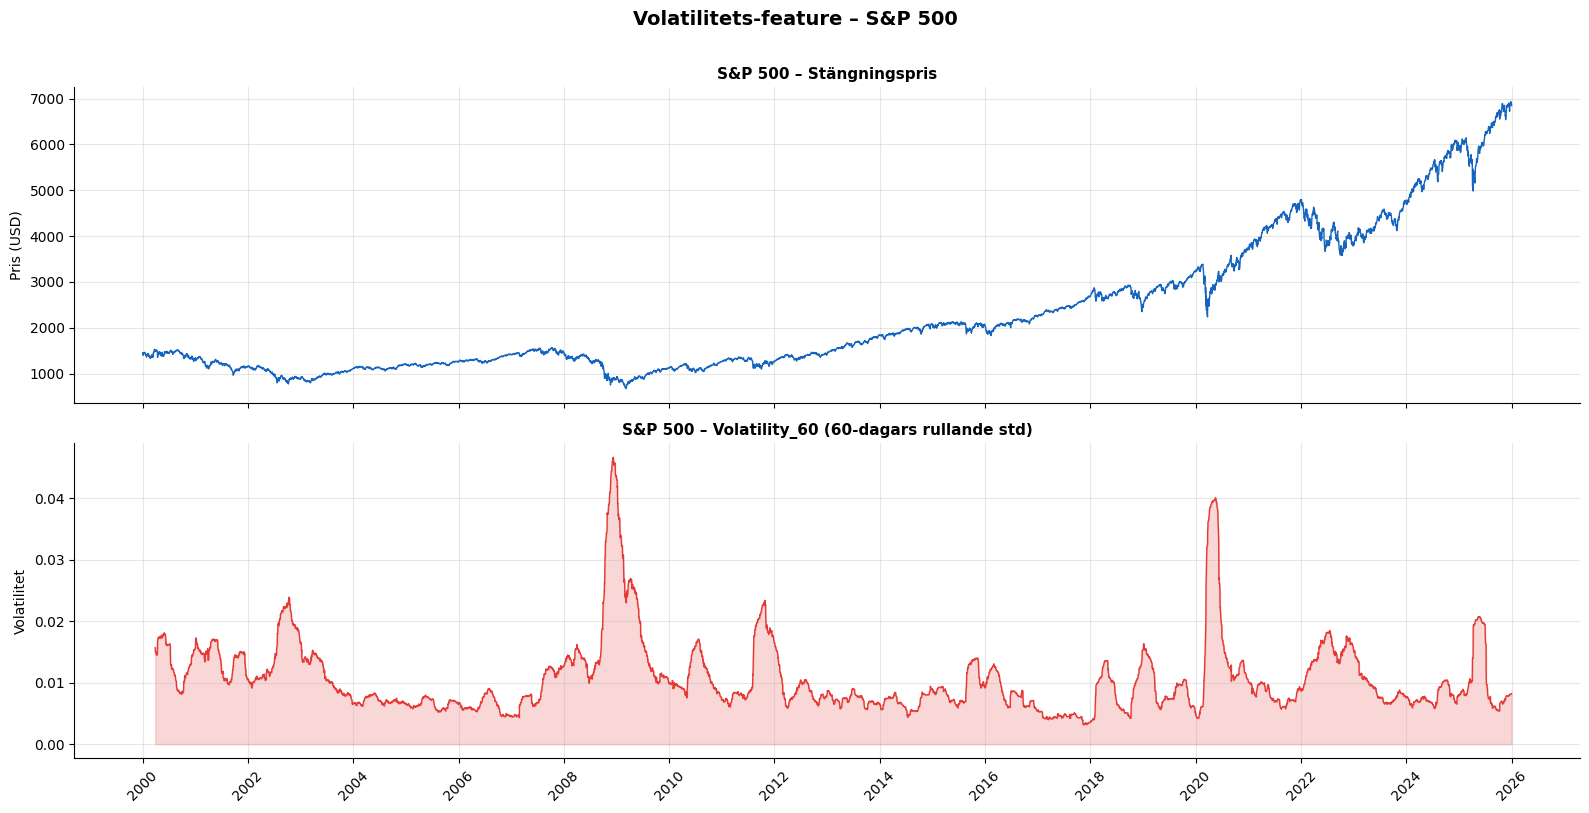

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

df = assets['SP500']

# Övre: Pris
axes[0].plot(df.index, df['Close'], color='#1565C0', linewidth=1, label='Close')
axes[0].set_title('S&P 500 – Stängningspris', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pris (USD)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Nedre: Volatility_60
axes[1].plot(df.index, df['Volatility_60'], color='#E53935', linewidth=1)
axes[1].fill_between(df.index, 0, df['Volatility_60'], alpha=0.2, color='#E53935')
axes[1].set_title('S&P 500 – Volatility_60 (60-dagars rullande std)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Volatilitet')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Volatilitets-feature – S&P 500', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_volatility.png'), dpi=150, bbox_inches='tight')
plt.show()

## Visualisering – Volatility_60

Grafen visar stängningspriset (övre) och Volatility_60 (nedre) för S&P 500.

Höga toppar i volatiliteten sammanfaller tydligt med kända kriser:
- **2002** – IT-bubblan spricker
- **2008–2009** – finanskrisen (högsta toppen, ~4.5%)
- **2020** – COVID-kraschen (~4%)
- **2022** – räntehöjningarna

Under lugna bull-marknader (2004–2007, 2013–2019) håller volatiliteten
sig konsekvent låg (~0.5–1%). Detta bekräftar att Volatility_60 är
en stark signal för bull/bear-klassificering.

## 4. Volym-feature

Volym bekräftar prisrörelser – en uppgång med hög volym är starkare än
en uppgång med låg volym. Under björnmarknader syns ofta onormalt hög
volym vid panikförsäljning.

**Volume_ratio** – dagens volym relativt 50-dagars genomsnittet.
Vi valde 50 dagar för att matcha det medellångsiktiga perspektivet
och undvika att enstaka extremdagar påverkar referensnivån.
Värden över 1.5 indikerar ovanligt hög aktivitet, vilket ofta
sammanfaller med regimskiften.

In [5]:
def add_volume_feature(df: pd.DataFrame) -> pd.DataFrame:
    volume = df['Volume']

    # Relativ volym – dagens volym vs 50-dagars snitt
    vol_ma50 = volume.rolling(50).mean()
    df['Volume_ratio'] = volume / vol_ma50

    return df

for name in assets:
    assets[name] = add_volume_feature(assets[name])
    print(f'✓ {name}: Volume_ratio tillagd')

✓ SP500: Volume_ratio tillagd
✓ Bitcoin: Volume_ratio tillagd


### Visualisera volym-features för S&P 500

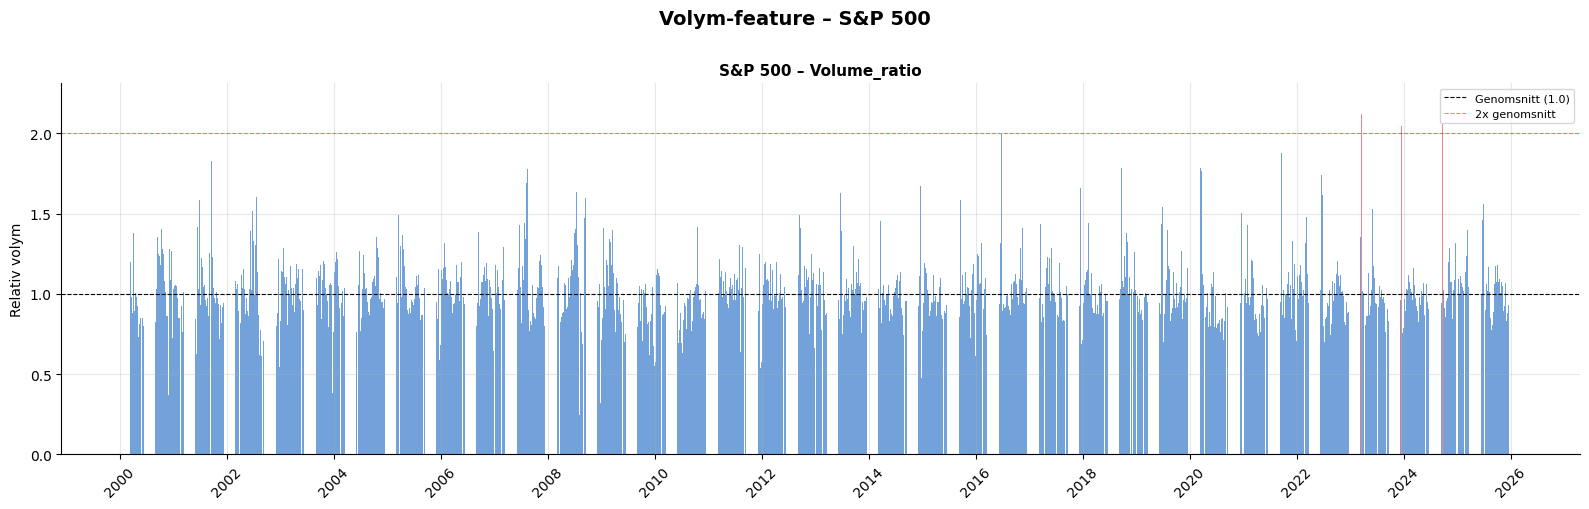

✓ Graf sparad: results/feature_volume.png


In [6]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))

df = assets['SP500']

ax.bar(df.index, df['Volume_ratio'],
       color=df['Volume_ratio'].apply(lambda x: '#E53935' if x > 2 else '#1565C0'),
       alpha=0.6, width=1)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='Genomsnitt (1.0)')
ax.axhline(2.0, color='red',   linewidth=0.8, linestyle='--', alpha=0.5, label='2x genomsnitt')
ax.set_title('S&P 500 – Volume_ratio', fontsize=11, fontweight='bold')
ax.set_ylabel('Relativ volym')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Volym-feature – S&P 500', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_volume.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/feature_volume.png')

## Visualisering – Volume_ratio

**Volume_ratio** visar dagens volym relativt 50-dagars genomsnittet:

- Ratio = 1.0 → normal volym
- Ratio = 2.0 → dubbel volym, ovanligt hög aktivitet (markerat i rött)
- Höga volymspikar sammanfaller ofta med stora prisrörelser och regimskiften

**Vad vi ser:** S&P 500 håller sig nära 1.0 med tydliga spikar under
finanskrisen 2008, COVID 2020 och räntehöjningarna 2022.

In [7]:
# ── Deskriptiv statistik: Volatility_60 och Volume_ratio ──────────
features_to_describe = ['Volatility_60', 'Volume_ratio']

print('═' * 70)
print('  Deskriptiv statistik — engineered features (SP500)')
print('═' * 70)

desc = df[features_to_describe].describe()

# Lägg till skewness och kurtosis (vanligt i finansiell deskriptiv statistik)
desc.loc['skewness'] = df[features_to_describe].skew()
desc.loc['kurtosis'] = df[features_to_describe].kurtosis()

display(desc.round(4))

══════════════════════════════════════════════════════════════════════
  Deskriptiv statistik — engineered features (SP500)
══════════════════════════════════════════════════════════════════════


,Volatility_60,Volume_ratio
count,6479.0000,6490.0000
mean,0.0106,1.0078
std,0.0061,0.1931
min,0.0031,0.0000
25%,0.0069,0.8987
50%,0.0086,0.9920
75%,0.0128,1.0934
max,0.0466,2.2006
skewness,2.5943,0.8498
kurtosis,9.2591,4.2168


## 5. Sammanställ och spara features

Nu sammanställer vi alla features och sparar dem. Vi tar bort rader med NaN som uppstår från rullande fönster (ex. MA200 kräver 200 rader innan den kan beräknas).

In [8]:
# Våra 2 features + grundkolumner
feature_cols = ['Volatility_60', 'Volume_ratio']
keep_cols    = ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return'] + feature_cols

print('— Slutliga features per tillgång ————————————')
for name in assets:
    df           = assets[name][keep_cols].dropna()
    assets[name] = df
    print(f'{name}: {len(feature_cols)} features')
    print(f'  {feature_cols}')
    print(f'  Rader efter dropna: {len(df)}\n')

— Slutliga features per tillgång ————————————
SP500: 2 features
  ['Volatility_60', 'Volume_ratio']
  Rader efter dropna: 6479

Bitcoin: 2 features
  ['Volatility_60', 'Volume_ratio']
  Rader efter dropna: 4064



In [9]:
# Spara separata feature-filer per tillgång
for name, df in assets.items():
    df_clean  = df.dropna()
    filename  = f'{name.lower()}_features.csv'
    filepath  = os.path.join(DATA_DIR, filename)
    df_clean.to_csv(filepath)
    print(f'✓ Sparad: data/{filename} ({len(df_clean)} rader efter dropna)')

✓ Sparad: data/sp500_features.csv (6479 rader efter dropna)
✓ Sparad: data/bitcoin_features.csv (4064 rader efter dropna)


## 6. Sammanfattning

Vi har skapat följande features per tillgång:


| Avkastning  | Return         | Daglig procentuell förändring (från nb02) |

| Volatilitet | Volatility_60  | 60 dagars rull. std|

| Volym       | Volume_ratio   | Volym / MA(Vol,50) |

| **Totalt**  |                | **3 features**     |


**Nästa steg:** `04_hmm.ipynb` – Hidden Markov Model för osupervised regimdetektering.